In [124]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [125]:
def measure_regions(binary_mask, min_area_pixels=0, include_rotated_rect=True):
    
    # Find connected components
    num_labels, labeled_img, stats, centroids = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=8
    )
    
    regions = []
    
    # Process each component (skip background which is label 0)
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        # Filter by minimum area
        if area < min_area_pixels:
            continue
        
        # Extract basic bounding box properties
        left = stats[i, cv2.CC_STAT_LEFT]
        top = stats[i, cv2.CC_STAT_TOP]
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        centroid = centroids[i]
        
        # Calculate aspect ratio
        aspect_ratio = width / height if height > 0 else 0
        
        # Calculate maximum length (diagonal of bounding box)
        max_length_bbox = np.sqrt(width**2 + height**2)
        
        # Find contour for this component
        component_mask = (labeled_img == i).astype(np.uint8) * 255
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        contour = contours[0] if len(contours) > 0 else np.array([])
        contour_length = len(contour)
        
        # Initialize region properties
        region_props = {
            'label': i,
            'area': int(area),
            'height': height,
            'width': width,
            'bbox': (left, top, width, height),
            'centroid': centroid,
            'aspect_ratio': aspect_ratio,
            'contour': contour,
            'contour_length': contour_length,
            'max_length_bbox': max_length_bbox
        }
        
        # Calculate rotated rectangle properties if requested
        if include_rotated_rect and len(contours) > 0:
            # Get the minimum area rectangle (rotated rectangle)
            rect = cv2.minAreaRect(contour)
            box = cv2.boxPoints(rect)
            box = np.intp(box)
            
            # Calculate the lengths of the rectangle sides
            side1 = np.linalg.norm(box[0] - box[1])
            side2 = np.linalg.norm(box[1] - box[2])
            max_length_actual = max(side1, side2)
            
            region_props['rotated_rect'] = box
            region_props['max_length_actual'] = max_length_actual
        
        regions.append(region_props)
    
    return regions, labeled_img, len(regions)

In [126]:
def visualize_detections(image, binary_mask, regions, title="Detection Results", 
                         show_height=True, show_width=False, show_area=True, 
                         show_centroid=True, show_rotated_rect=False):

    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_result = img_rgb.copy()
    
    # Create colored overlay
    overlay = img_rgb.copy()
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for region in regions:
        # Random color for each region
        color = np.random.randint(0, 255, 3).tolist()
        cv2.drawContours(overlay, [region['contour']], -1, color, -1)
    
    # Blend overlay with original
    img_result = cv2.addWeighted(img_rgb, 0.6, overlay, 0.4, 0)
    
    # Draw contours
    cv2.drawContours(img_result, contours, -1, (255, 255, 0), 2)
    
    # Draw annotations for each region
    for idx, region in enumerate(regions, 1):
        x, y, w, h = region['bbox']
        
        # Draw regular bounding box
        cv2.rectangle(img_result, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
        # Draw rotated rectangle if requested
        if show_rotated_rect and 'rotated_rect' in region:
            cv2.drawContours(img_result, [region['rotated_rect']], 0, (255, 0, 0), 2)
        
        # Draw centroid
        if show_centroid:
            cx, cy = int(region['centroid'][0]), int(region['centroid'][1])
            cv2.circle(img_result, (cx, cy), 5, (255, 0, 0), -1)
        
        # Draw height measurement
        if show_height:
            cv2.line(img_result, (x + w + 5, y), (x + w + 5, y + h), (255, 0, 255), 2)
            cv2.putText(img_result, f"H:{h}px", (x + w + 10, y + h // 2), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)
        
        # Draw width measurement
        if show_width:
            cv2.line(img_result, (x, y - 5), (x + w, y - 5), (0, 255, 255), 2)
            cv2.putText(img_result, f"W:{w}px", (x + w // 2 - 30, y - 10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
        
        # Draw area text
        if show_area:
            area_text = f"#{idx}: {region['area']}px"
            cv2.putText(img_result, area_text, (x, y - 5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(binary_mask, cmap='gray')
    axes[1].set_title(f'Binary Mask ({len(regions)} regions)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(img_result)
    axes[2].set_title(title, fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    total_area = sum(r['area'] for r in regions)
    img_area = image.shape[0] * image.shape[1]
    
    print(f"\n{'='*60}")
    print(f"  {title.upper()}")
    print(f"{'='*60}")
    print(f"Number of regions: {len(regions)}")
    print(f"Total area: {total_area:,} pixels ({total_area/img_area*100:.2f}%)")
    print(f"\nIndividual Regions:")
    print(f"{'-'*60}")
    
    for idx, region in enumerate(regions, 1):
        x, y, w, h = region['bbox']
        cx, cy = region['centroid']
        print(f"  Region {idx}:")
        print(f"    Area: {region['area']:,} pixels")
        print(f"    Size: {region['width']}px (W) × {region['height']}px (H)")
        print(f"    Aspect Ratio: {region['aspect_ratio']:.2f}")
        print(f"    Centroid: ({cx:.1f}, {cy:.1f})")
        if 'max_length_actual' in region:
            print(f"    Max Length: {region['max_length_actual']:.2f} pixels")
    print(f"{'='*60}\n")

In [127]:
def detect_objects_chromaticity(image, chroma_grad_threshold=30, sat_threshold=40, 
                                smoothing_kernel=5, morph_kernel=7):
    
    # Convert to Lab color space
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    
    # Convert to HSV for saturation
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h_channel, s_channel, v_channel = cv2.split(hsv)
    
    # Apply Gaussian blur for smooth gradients
    a_smooth = cv2.GaussianBlur(a_channel, (smoothing_kernel, smoothing_kernel), 0)
    b_smooth = cv2.GaussianBlur(b_channel, (smoothing_kernel, smoothing_kernel), 0)
    
    # Compute gradients using Sobel operator
    a_grad_x = cv2.Sobel(a_smooth, cv2.CV_64F, 1, 0, ksize=3)
    a_grad_y = cv2.Sobel(a_smooth, cv2.CV_64F, 0, 1, ksize=3)
    b_grad_x = cv2.Sobel(b_smooth, cv2.CV_64F, 1, 0, ksize=3)
    b_grad_y = cv2.Sobel(b_smooth, cv2.CV_64F, 0, 1, ksize=3)
    
    # Combined chromaticity gradient magnitude
    chroma_gradient = np.sqrt(a_grad_x**2 + a_grad_y**2 + b_grad_x**2 + b_grad_y**2)
    chroma_gradient_norm = np.uint8((chroma_gradient / chroma_gradient.max() * 255))
    
    # Detect object boundaries
    _, chroma_edges = cv2.threshold(chroma_gradient_norm, chroma_grad_threshold, 255, cv2.THRESH_BINARY)
    
    # Saturation mask
    _, sat_mask = cv2.threshold(s_channel, sat_threshold, 255, cv2.THRESH_BINARY)
    
    # Dilate chromaticity edges
    kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    chroma_edges_dilated = cv2.dilate(chroma_edges, kernel_dilate, iterations=2)
    
    # Combine with saturation
    object_mask = cv2.bitwise_and(sat_mask, chroma_edges_dilated)
    
    # Morphological refinement
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel, morph_kernel))
    object_mask = cv2.morphologyEx(object_mask, cv2.MORPH_CLOSE, kernel_morph, iterations=3)
    object_mask = cv2.morphologyEx(object_mask, cv2.MORPH_OPEN, kernel_morph, iterations=1)
    
    # Fill holes
    contours, _ = cv2.findContours(object_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    object_mask_final = np.zeros_like(object_mask)
    cv2.drawContours(object_mask_final, contours, -1, 255, thickness=cv2.FILLED)
    
    return object_mask_final

In [128]:
def detect_shadows(image):
    
    # Convert to different color spaces
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # HSV-based shadow detection (low value)
    lower_shadow_hsv = np.array([0, 0, 0])
    upper_shadow_hsv = np.array([180, 255, 100])
    shadow_mask_hsv = cv2.inRange(hsv, lower_shadow_hsv, upper_shadow_hsv)
    
    # Lab-based shadow detection (low lightness)
    l_channel = lab[:, :, 0]
    shadow_mask_lab = cv2.threshold(l_channel, 80, 255, cv2.THRESH_BINARY_INV)[1]
    
    # Combine both methods
    combined_shadow_mask = cv2.bitwise_or(shadow_mask_hsv, shadow_mask_lab)
    
    # Morphological cleanup
    kernel = np.ones((5, 5), np.uint8)
    combined_shadow_mask = cv2.morphologyEx(combined_shadow_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    combined_shadow_mask = cv2.morphologyEx(combined_shadow_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    return combined_shadow_mask

In [129]:
def match_objects_with_shadows(object_regions, shadow_regions, max_distance=200):
    
    matches = []
    used_shadows = set()
    
    for obj in object_regions:
        obj_centroid = np.array(obj['centroid'])
        
        min_distance = float('inf')
        closest_shadow = None
        closest_shadow_idx = None
        
        # Find the closest shadow to this object
        for idx, shadow in enumerate(shadow_regions):
            if idx in used_shadows:
                continue
                
            shadow_centroid = np.array(shadow['centroid'])
            distance = np.linalg.norm(obj_centroid - shadow_centroid)
            
            if distance < min_distance:
                min_distance = distance
                closest_shadow = shadow
                closest_shadow_idx = idx
        
        # Only keep shadow if within max_distance
        if closest_shadow is not None and min_distance <= max_distance:
            used_shadows.add(closest_shadow_idx)
            matches.append({
                'object': obj,
                'shadow': closest_shadow,
                'distance': min_distance
            })
        else:
            # Object with no nearby shadow
            matches.append({
                'object': obj,
                'shadow': None,
                'distance': None
            })
    
    return matches

In [130]:
def visualize_object_shadow_pairs(image, matches, title="Object-Shadow Pairs"):
    
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_result = img_rgb.copy()
    
    # Create masks for matched objects and shadows only
    object_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    shadow_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    
    # Draw each matched pair
    for idx, match in enumerate(matches, 1):
        obj = match['object']
        shadow = match['shadow']
        
        # Generate a unique color for this pair
        pair_color = np.random.randint(50, 255, 3).tolist()
        
        # Draw object
        cv2.drawContours(object_mask, [obj['contour']], -1, 255, -1)
        cv2.drawContours(img_result, [obj['contour']], -1, pair_color, 3)
        
        obj_x, obj_y, obj_w, obj_h = obj['bbox']
        obj_cx, obj_cy = int(obj['centroid'][0]), int(obj['centroid'][1])
        
        # Draw object bounding box and centroid
        cv2.rectangle(img_result, (obj_x, obj_y), (obj_x + obj_w, obj_y + obj_h), (0, 255, 0), 2)
        cv2.circle(img_result, (obj_cx, obj_cy), 6, (255, 0, 0), -1)
        
        # Draw object height
        cv2.line(img_result, (obj_x + obj_w + 5, obj_y), (obj_x + obj_w + 5, obj_y + obj_h), (255, 0, 255), 2)
        cv2.putText(img_result, f"H:{obj_h}px", (obj_x + obj_w + 10, obj_y + obj_h // 2),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)
        
        # Draw object label
        cv2.putText(img_result, f"Obj-{idx}", (obj_x, obj_y - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.putText(img_result, f"A:{obj['area']}px", (obj_x, obj_y - 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # Draw shadow if it exists
        if shadow is not None:
            cv2.drawContours(shadow_mask, [shadow['contour']], -1, 255, -1)
            cv2.drawContours(img_result, [shadow['contour']], -1, pair_color, 2)
            
            shadow_x, shadow_y, shadow_w, shadow_h = shadow['bbox']
            shadow_cx, shadow_cy = int(shadow['centroid'][0]), int(shadow['centroid'][1])
            
            # Draw shadow bounding box and centroid
            cv2.rectangle(img_result, (shadow_x, shadow_y), (shadow_x + shadow_w, shadow_y + shadow_h), (255, 165, 0), 2)
            cv2.circle(img_result, (shadow_cx, shadow_cy), 6, (0, 0, 255), -1)
            
            # Draw shadow height
            cv2.line(img_result, (shadow_x + shadow_w + 5, shadow_y), (shadow_x + shadow_w + 5, shadow_y + shadow_h), (0, 255, 255), 2)
            cv2.putText(img_result, f"H:{shadow_h}px", (shadow_x + shadow_w + 10, shadow_y + shadow_h // 2),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
            
            # Draw shadow label
            cv2.putText(img_result, f"Shadow-{idx}", (shadow_x, shadow_y - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 165, 0), 2)
            cv2.putText(img_result, f"A:{shadow['area']}px", (shadow_x, shadow_y - 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 165, 0), 2)
            
            # Draw connection line between object and shadow
            cv2.line(img_result, (obj_cx, obj_cy), (shadow_cx, shadow_cy), pair_color, 2, cv2.LINE_AA)
            
            # Draw distance text at midpoint
            mid_x = (obj_cx + shadow_cx) // 2
            mid_y = (obj_cy + shadow_cy) // 2
            cv2.putText(img_result, f"{match['distance']:.0f}px", (mid_x, mid_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(object_mask, cmap='gray')
    axes[0, 1].set_title(f'Matched Objects ({len(matches)} objects)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(shadow_mask, cmap='gray')
    matched_shadows = sum(1 for m in matches if m['shadow'] is not None)
    axes[1, 0].set_title(f'Matched Shadows ({matched_shadows} shadows)', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(img_result)
    axes[1, 1].set_title(title, fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print(f"\n{'='*70}")
    print(f"  {title.upper()}")
    print(f"{'='*70}")
    print(f"Total objects: {len(matches)}")
    
    matched_count = sum(1 for m in matches if m['shadow'] is not None)
    unmatched_count = len(matches) - matched_count
    
    print(f"Objects with shadows: {matched_count}")
    print(f"Objects without shadows: {unmatched_count}")
    
    print(f"\nObject-Shadow Pairs:")
    print(f"{'-'*70}")
    
    for idx, match in enumerate(matches, 1):
        obj = match['object']
        shadow = match['shadow']
        
        print(f"\n  Pair {idx}:")
        print(f"    Object:")
        print(f"      Area: {obj['area']:,} pixels")
        print(f"      Size: {obj['width']}px (W) × {obj['height']}px (H)")
        print(f"      Centroid: ({obj['centroid'][0]:.1f}, {obj['centroid'][1]:.1f})")
        
        if shadow is not None:
            print(f"    Shadow:")
            print(f"      Area: {shadow['area']:,} pixels")
            print(f"      Size: {shadow['width']}px (W) × {shadow['height']}px (H)")
            print(f"      Centroid: ({shadow['centroid'][0]:.1f}, {shadow['centroid'][1]:.1f})")
            print(f"    Distance: {match['distance']:.2f} pixels")
        else:
            print(f"    Shadow: None (no shadow within range)")
    
    print(f"{'='*70}\n")

In [131]:
def calculate_sun_angle(match, use_shadow_length=True):

    obj = match['object']
    shadow = match['shadow']
    
    # Check if shadow exists
    if shadow is None:
        return {
            'theta_degrees': None,
            'theta_radians': None,
            'object_height': obj['height'],
            'shadow_length': None,
            'ratio': None,
            'valid': False
        }
    
    # Get object height
    object_height = obj['height']
    
    # Calculate shadow length
    if use_shadow_length:
        # Use the maximum dimension of the shadow (width or height)
        shadow_length = max(shadow['width'], shadow['height'])
    else:
        # Use the distance between centroids
        shadow_length = match['distance']
    
    # Avoid division by zero
    if shadow_length == 0:
        return {
            'theta_degrees': None,
            'theta_radians': None,
            'object_height': object_height,
            'shadow_length': shadow_length,
            'ratio': None,
            'valid': False
        }
    
    # Calculate ratio
    ratio = object_height / shadow_length
    
    # Calculate theta using arctan
    theta_radians = np.arctan(ratio)
    theta_degrees = np.degrees(theta_radians)
    
    return {
        'theta_degrees': theta_degrees,
        'theta_radians': theta_radians,
        'object_height': object_height,
        'shadow_length': shadow_length,
        'ratio': ratio,
        'valid': True
    }

In [132]:
def visualize_with_sun_angle(image, matches, title="Object-Shadow Analysis with Sun Angle"):
    
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_result = img_rgb.copy()
    
    # Draw each matched pair with angle information
    for idx, match in enumerate(matches, 1):
        obj = match['object']
        shadow = match['shadow']
        
        # Calculate sun angle
        angle_info = calculate_sun_angle(match, use_shadow_length=True)
        
        # Generate a unique color for this pair
        pair_color = np.random.randint(50, 255, 3).tolist()
        
        # Draw object
        cv2.drawContours(img_result, [obj['contour']], -1, pair_color, 3)
        
        obj_x, obj_y, obj_w, obj_h = obj['bbox']
        obj_cx, obj_cy = int(obj['centroid'][0]), int(obj['centroid'][1])
        
        # Draw object bounding box and centroid
        cv2.rectangle(img_result, (obj_x, obj_y), (obj_x + obj_w, obj_y + obj_h), (0, 255, 0), 2)
        cv2.circle(img_result, (obj_cx, obj_cy), 6, (255, 0, 0), -1)
        
        # Draw object height with arrow
        cv2.arrowedLine(img_result, (obj_x + obj_w + 10, obj_y + obj_h), 
                        (obj_x + obj_w + 10, obj_y), (255, 0, 255), 3, tipLength=0.05)
        cv2.putText(img_result, f"H:{obj_h}px", (obj_x + obj_w + 20, obj_y + obj_h // 2),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)
        
        # Draw object label
        cv2.putText(img_result, f"Object-{idx}", (obj_x, obj_y - 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
        # Draw shadow if it exists
        if shadow is not None and angle_info['valid']:
            cv2.drawContours(img_result, [shadow['contour']], -1, pair_color, 2)
            
            shadow_x, shadow_y, shadow_w, shadow_h = shadow['bbox']
            shadow_cx, shadow_cy = int(shadow['centroid'][0]), int(shadow['centroid'][1])
            shadow_length = angle_info['shadow_length']
            
            # Draw shadow bounding box and centroid
            cv2.rectangle(img_result, (shadow_x, shadow_y), (shadow_x + shadow_w, shadow_y + shadow_h), (255, 165, 0), 2)
            cv2.circle(img_result, (shadow_cx, shadow_cy), 6, (0, 0, 255), -1)
            
            # Draw shadow length
            if shadow_w > shadow_h:
                # Horizontal shadow
                cv2.arrowedLine(img_result, (shadow_x, shadow_y - 10), 
                               (shadow_x + shadow_w, shadow_y - 10), (0, 255, 255), 3, tipLength=0.02)
                cv2.putText(img_result, f"L:{int(shadow_length)}px", 
                           (shadow_x + shadow_w // 2 - 40, shadow_y - 20),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
            else:
                # Vertical shadow
                cv2.arrowedLine(img_result, (shadow_x + shadow_w + 10, shadow_y + shadow_h), 
                               (shadow_x + shadow_w + 10, shadow_y), (0, 255, 255), 3, tipLength=0.02)
                cv2.putText(img_result, f"L:{int(shadow_length)}px", 
                           (shadow_x + shadow_w + 20, shadow_y + shadow_h // 2),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
            
            # Draw shadow label
            cv2.putText(img_result, f"Shadow-{idx}", (shadow_x, shadow_y - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 165, 0), 2)
            
            # Draw connection line between object and shadow
            cv2.line(img_result, (obj_cx, obj_cy), (shadow_cx, shadow_cy), pair_color, 2, cv2.LINE_AA)
            
            # Draw angle information box
            theta = angle_info['theta_degrees']
            text_x = min(obj_x, shadow_x)
            text_y = max(obj_y + obj_h, shadow_y + shadow_h) + 40
            
            # Create background rectangle for text
            box_padding = 10
            text_lines = [
                f"Sun Angle (θ): {theta:.2f}°",
                f"Ratio: {angle_info['ratio']:.3f}",
                f"Distance: {match['distance']:.0f}px"
            ]
            
            max_text_width = max([cv2.getTextSize(line, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0][0] 
                                 for line in text_lines])
            box_height = 30 * len(text_lines)
            
            # Draw semi-transparent background
            overlay = img_result.copy()
            cv2.rectangle(overlay, (text_x, text_y), 
                         (text_x + max_text_width + 2*box_padding, text_y + box_height + box_padding),
                         (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.7, img_result, 0.3, 0, img_result)
            
            # Draw text lines
            for i, line in enumerate(text_lines):
                cv2.putText(img_result, line, (text_x + box_padding, text_y + 25 + i*30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Display result
    plt.figure(figsize=(18, 12))
    plt.imshow(img_result)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics with angles
    print(f"\n{'='*80}")
    print(f"  {title.upper()}")
    print(f"{'='*80}")
    print(f"Total object-shadow pairs: {len(matches)}")
    
    valid_angles = [calculate_sun_angle(m) for m in matches if calculate_sun_angle(m)['valid']]
    
    if valid_angles:
        avg_angle = np.mean([a['theta_degrees'] for a in valid_angles])
        print(f"Average sun elevation angle: {avg_angle:.2f}°")
    
    print(f"\nDetailed Analysis:")
    print(f"{'-'*80}")
    
    for idx, match in enumerate(matches, 1):
        obj = match['object']
        shadow = match['shadow']
        angle_info = calculate_sun_angle(match)
        
        print(f"\n  Pair {idx}:")
        print(f"    Object Height: {obj['height']} pixels")
        
        if angle_info['valid']:
            print(f"    Shadow Length: {angle_info['shadow_length']:.0f} pixels")
            print(f"    Height/Length Ratio: {angle_info['ratio']:.3f}")
            print(f"    Sun Elevation Angle (θ): {angle_info['theta_degrees']:.2f}° ({angle_info['theta_radians']:.4f} rad)")
            print(f"    Centroid Distance: {match['distance']:.2f} pixels")
            print(f"    Formula: θ = arctan({obj['height']}/{angle_info['shadow_length']:.0f}) = {angle_info['theta_degrees']:.2f}°")
        else:
            print(f"    Shadow: Not available")
            print(f"    Sun Angle: Cannot be calculated")
    
    print(f"{'='*80}\n")

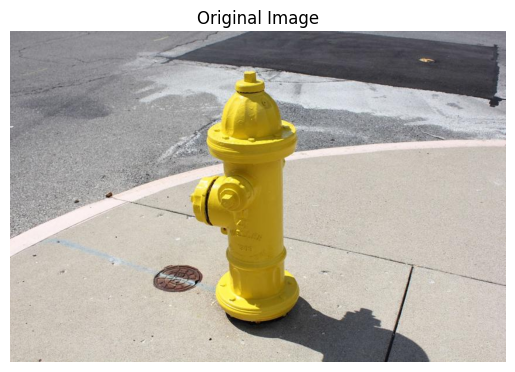

In [133]:
# Load image
img = cv2.imread("./test2.jpg", 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.show()

EXAMPLE 1: OBJECT DETECTION


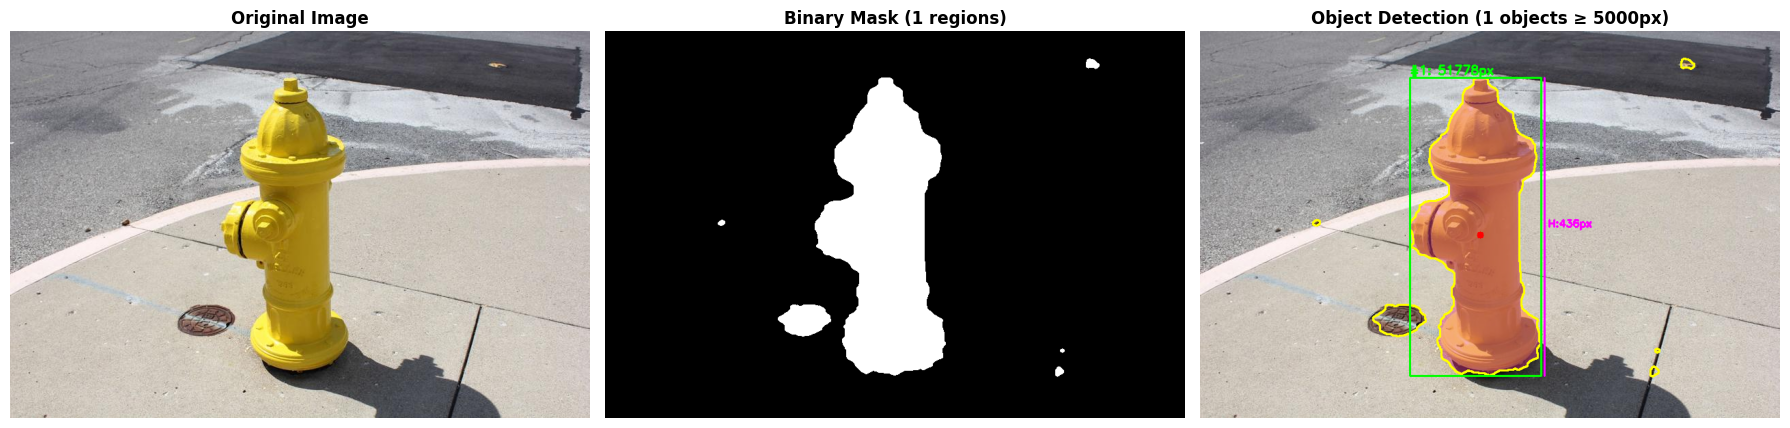


  OBJECT DETECTION (1 OBJECTS ≥ 5000PX)
Number of regions: 1
Total area: 51,778 pixels (10.78%)

Individual Regions:
------------------------------------------------------------
  Region 1:
    Area: 51,778 pixels
    Size: 192px (W) × 436px (H)
    Aspect Ratio: 0.44
    Centroid: (410.6, 298.2)



In [134]:
# Example 1: Detect objects with chromaticity gradient
print("="*60)
print("EXAMPLE 1: OBJECT DETECTION")
print("="*60)

# Step 1: Detect objects (returns only binary mask)
object_mask = detect_objects_chromaticity(
    img,
    chroma_grad_threshold=30,
    sat_threshold=40,
    smoothing_kernel=5,
    morph_kernel=7
)

# Step 2: Measure regions (filter by minimum area)
object_regions, labeled_img, num_objects = measure_regions(
    object_mask,
    min_area_pixels=5000,
    include_rotated_rect=False
)

# Step 3: Visualize results
visualize_detections(
    img,
    object_mask,
    object_regions,
    title=f"Object Detection ({num_objects} objects ≥ 5000px)",
    show_height=True,
    show_area=True,
    show_centroid=True
)


EXAMPLE 2: SHADOW DETECTION


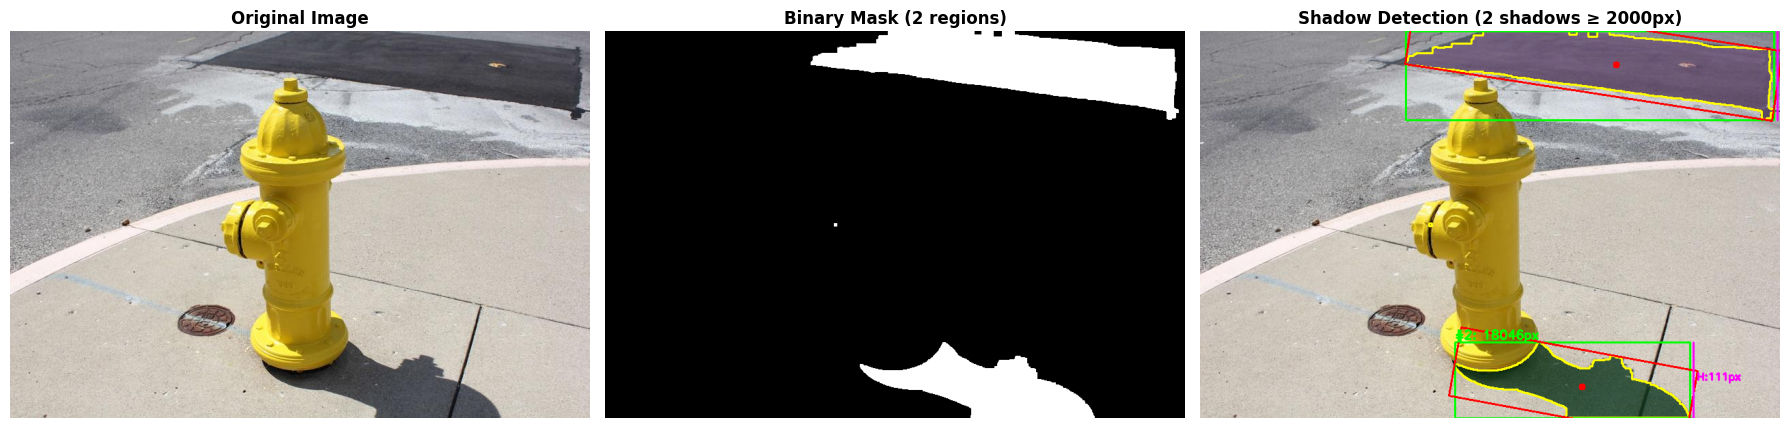


  SHADOW DETECTION (2 SHADOWS ≥ 2000PX)
Number of regions: 2
Total area: 55,511 pixels (11.55%)

Individual Regions:
------------------------------------------------------------
  Region 1:
    Area: 37,465 pixels
    Size: 539px (W) × 130px (H)
    Aspect Ratio: 4.15
    Centroid: (609.6, 49.3)
    Max Length: 543.07 pixels
  Region 2:
    Area: 18,046 pixels
    Size: 344px (W) × 111px (H)
    Aspect Ratio: 3.10
    Centroid: (559.1, 520.5)
    Max Length: 351.87 pixels



In [135]:
# Example 2: Detect shadows
print("\n" + "="*60)
print("EXAMPLE 2: SHADOW DETECTION")
print("="*60)

# Step 1: Detect shadows (returns only binary mask)
shadow_mask = detect_shadows(img)

# Step 2: Measure regions (filter by minimum area)
shadow_regions, labeled_img, num_shadows = measure_regions(
    shadow_mask,
    min_area_pixels=2000,
    include_rotated_rect=True
)

# Step 3: Visualize results
visualize_detections(
    img,
    shadow_mask,
    shadow_regions,
    title=f"Shadow Detection ({num_shadows} shadows ≥ 2000px)",
    show_height=True,
    show_area=True,
    show_centroid=True,
    show_rotated_rect=True
)


EXAMPLE 4: OBJECT-SHADOW MATCHING


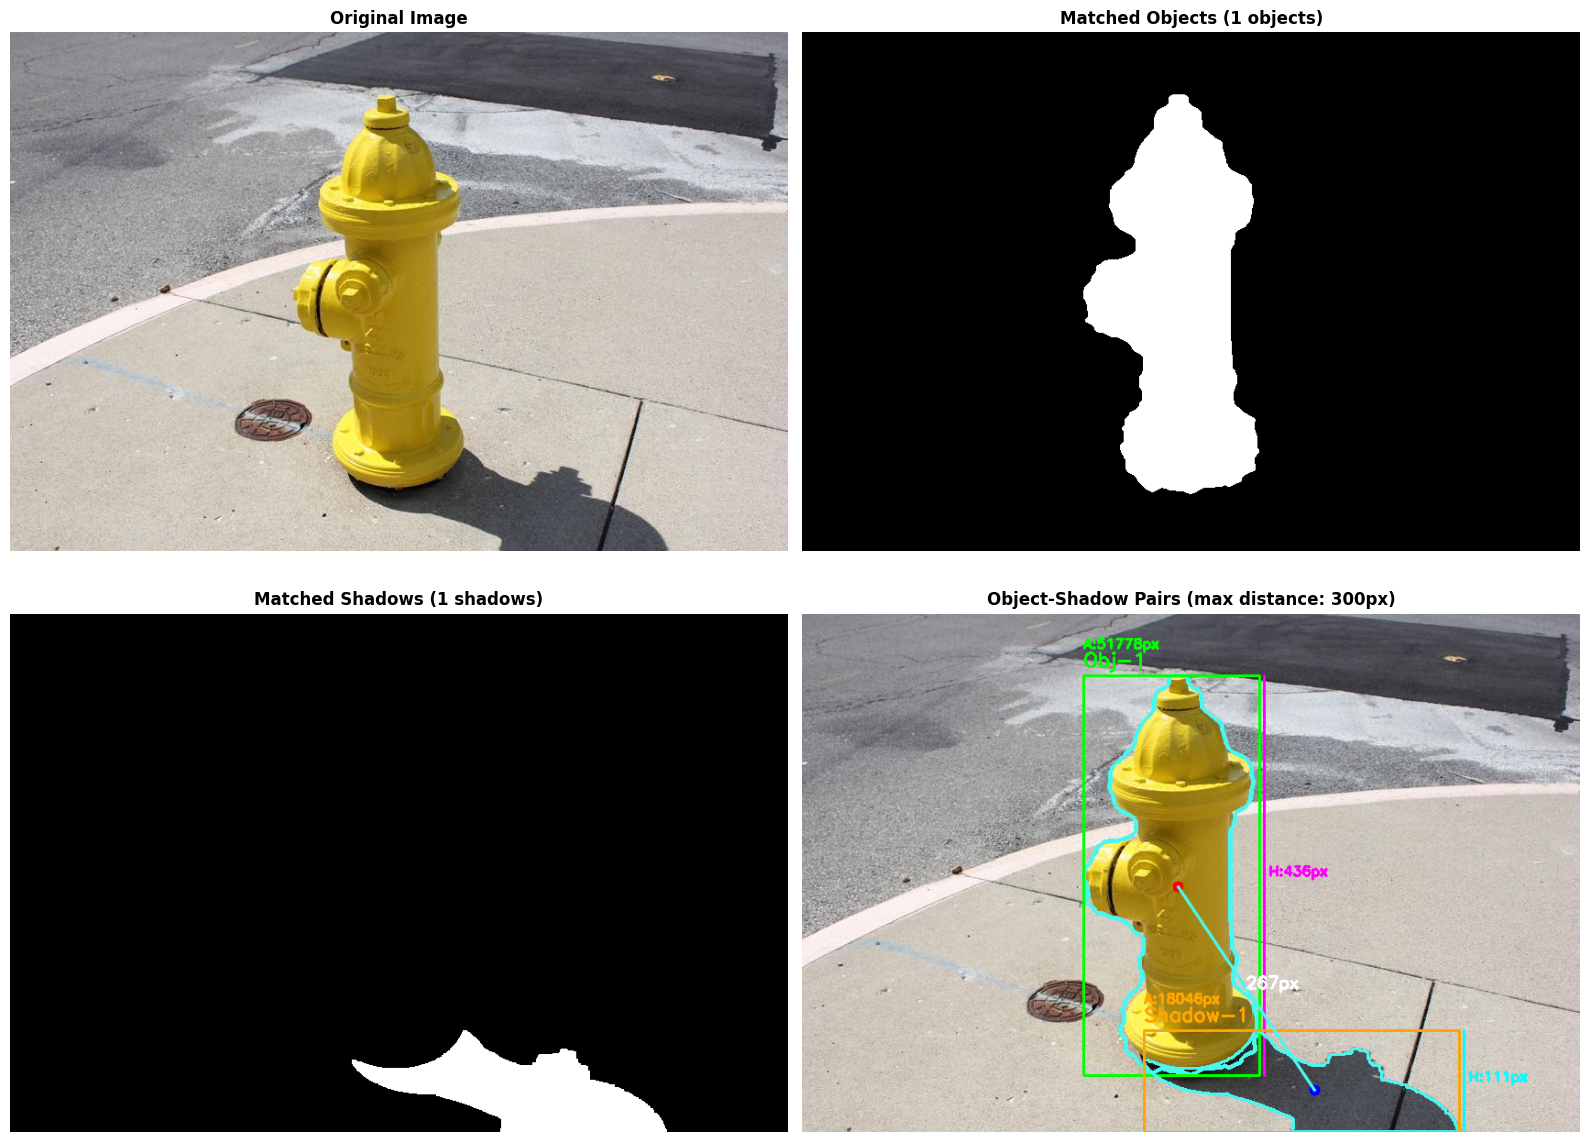


  OBJECT-SHADOW PAIRS (MAX DISTANCE: 300PX)
Total objects: 1
Objects with shadows: 1
Objects without shadows: 0

Object-Shadow Pairs:
----------------------------------------------------------------------

  Pair 1:
    Object:
      Area: 51,778 pixels
      Size: 192px (W) × 436px (H)
      Centroid: (410.6, 298.2)
    Shadow:
      Area: 18,046 pixels
      Size: 344px (W) × 111px (H)
      Centroid: (559.1, 520.5)
    Distance: 267.34 pixels



In [136]:
# Example 4: Match objects with their closest shadows
print("\n" + "="*70)
print("EXAMPLE 4: OBJECT-SHADOW MATCHING")
print("="*70)

# Step 1: Detect objects
object_mask = detect_objects_chromaticity(img)
object_regions, _, num_objects = measure_regions(object_mask, min_area_pixels=5000, include_rotated_rect=False)

# Step 2: Detect shadows
shadow_mask = detect_shadows(img)
shadow_regions, _, num_shadows = measure_regions(shadow_mask, min_area_pixels=2000, include_rotated_rect=False)

# Step 3: Match objects with their closest shadows
matches = match_objects_with_shadows(
    object_regions, 
    shadow_regions, 
    max_distance=300  # Maximum distance in pixels to consider a shadow as belonging to an object
)

# Step 4: Visualize only matched pairs
visualize_object_shadow_pairs(
    img,
    matches,
    title=f"Object-Shadow Pairs (max distance: 300px)"
)


EXAMPLE 5: SUN ANGLE CALCULATION

Pair 1:
  Object Height: 436 pixels
  Shadow Length: 344 pixels
  Ratio (H/L): 1.2674
  Sun Elevation Angle (θ): 51.73°
  Formula: tan(θ) = 436/344
           θ = arctan(1.2674) = 51.73°


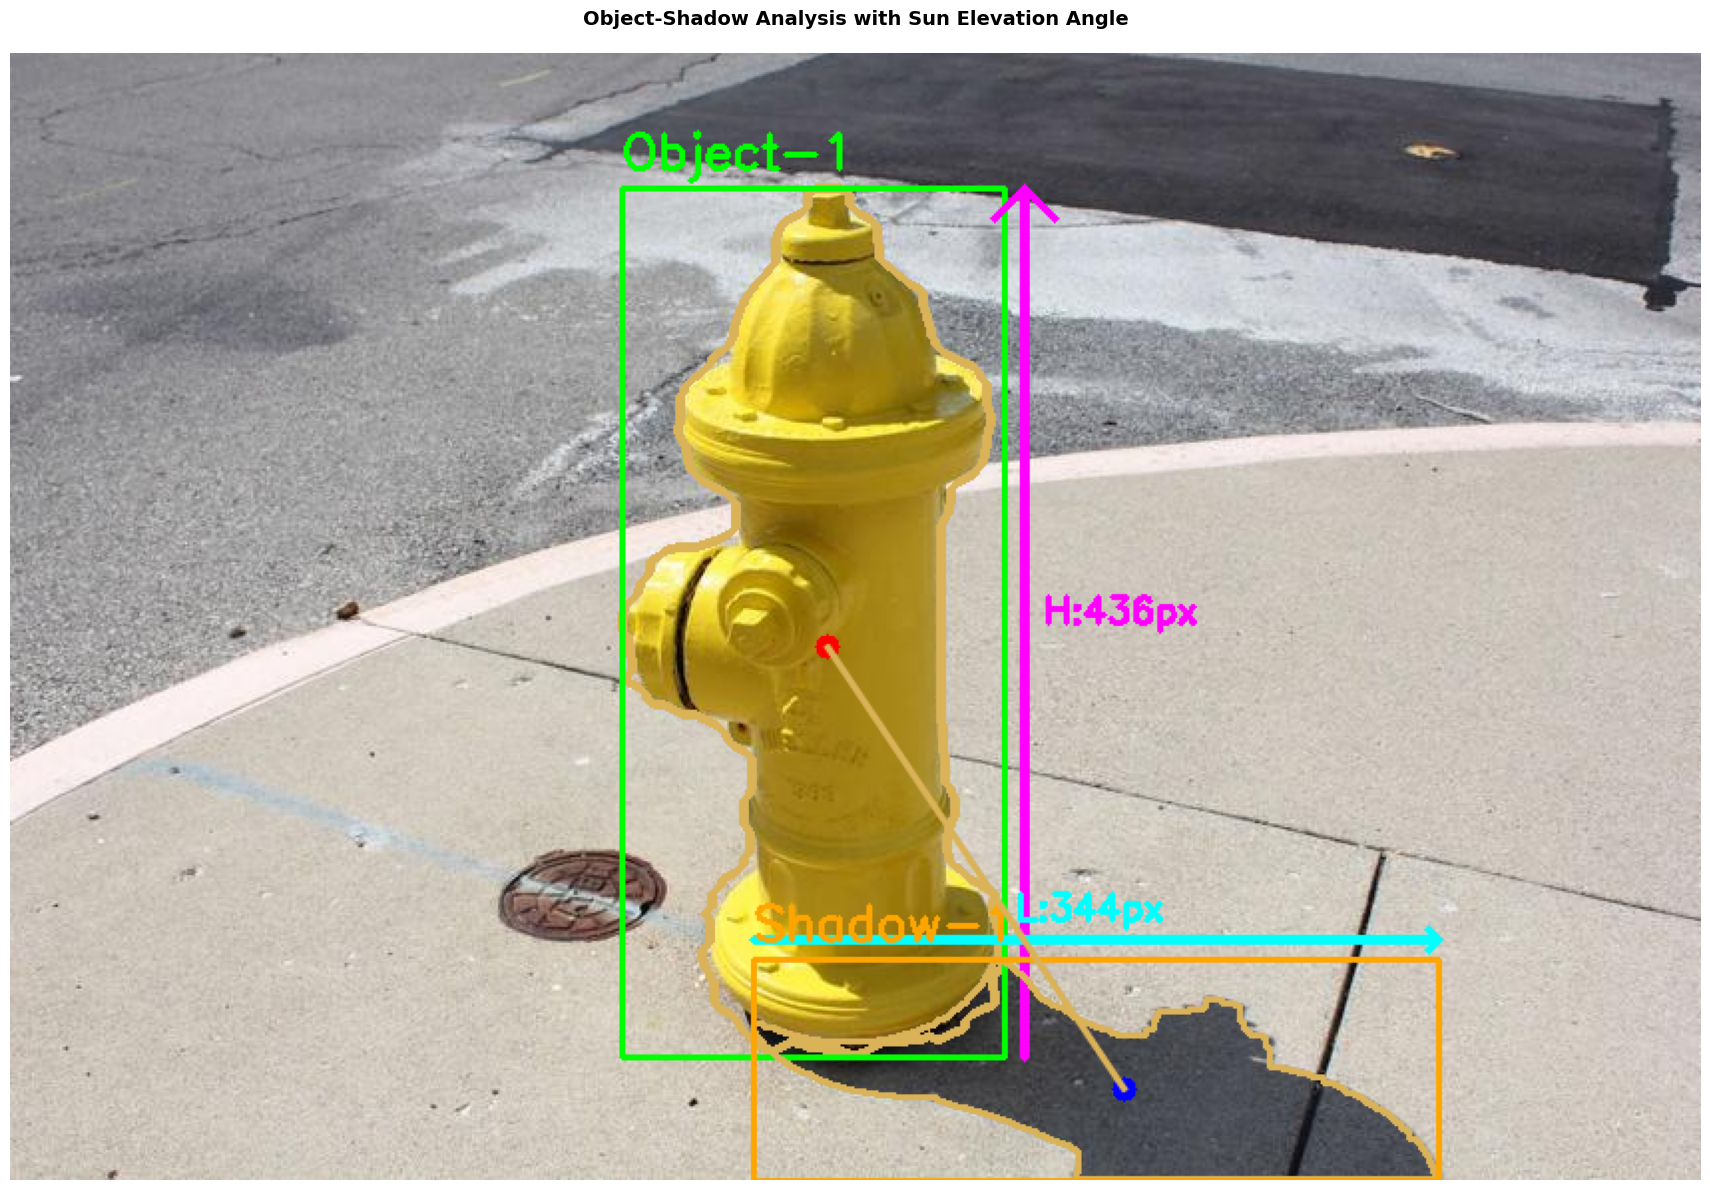


  OBJECT-SHADOW ANALYSIS WITH SUN ELEVATION ANGLE
Total object-shadow pairs: 1
Average sun elevation angle: 51.73°

Detailed Analysis:
--------------------------------------------------------------------------------

  Pair 1:
    Object Height: 436 pixels
    Shadow Length: 344 pixels
    Height/Length Ratio: 1.267
    Sun Elevation Angle (θ): 51.73° (0.9028 rad)
    Centroid Distance: 267.34 pixels
    Formula: θ = arctan(436/344) = 51.73°



In [137]:
# Example 5: Calculate sun elevation angle (theta)
print("\n" + "="*80)
print("EXAMPLE 5: SUN ANGLE CALCULATION")
print("="*80)

# Use existing matches from previous example
# Calculate theta for each match
for idx, match in enumerate(matches, 1):
    angle_info = calculate_sun_angle(match, use_shadow_length=True)
    
    print(f"\nPair {idx}:")
    if angle_info['valid']:
        print(f"  Object Height: {angle_info['object_height']} pixels")
        print(f"  Shadow Length: {angle_info['shadow_length']:.0f} pixels")
        print(f"  Ratio (H/L): {angle_info['ratio']:.4f}")
        print(f"  Sun Elevation Angle (θ): {angle_info['theta_degrees']:.2f}°")
        print(f"  Formula: tan(θ) = {angle_info['object_height']}/{angle_info['shadow_length']:.0f}")
        print(f"           θ = arctan({angle_info['ratio']:.4f}) = {angle_info['theta_degrees']:.2f}°")
    else:
        print(f"  No shadow detected - cannot calculate angle")

# Visualize with sun angle annotations
visualize_with_sun_angle(img, matches, title="Object-Shadow Analysis with Sun Elevation Angle")